# Predictive Modeling:
- 오늘 수업은 예측모델링 실험 방법
- 분류 및 회귀 모델을 구축하고 성능 평가

## 1. Tabular Data / Regression Models / sklearn 라이브러리 예측모델 성능평가
  1. 데이터 로드 (data load)
    - california_housing data_train,
    - california_housing_test
  2. 데이터 전처리 (data preprocessing)
    - imputation: simple imputer
    - normalization: standard scaler
  3. 예측 모델링 (predictive modeling)
    - Linear Regression, Random Forest Regressor, MLP regressor
    - random seed: data split, model initialization
  4. 실험 (experiments)
    - 10 replications with different random seeds
    - grid search to select best model
  5. 성능 평가 (performance evaluation)
    - r2, mape, mae, rmse, mse


In [ ]:
import random
import numpy as np
import pandas as pd

from scipy.stats import mstats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

import torch

In [ ]:
# Load data
data_train = pd.read_csv('./sample_data/california_housing_train.csv')
data_test = pd.read_csv('./sample_data/california_housing_test.csv')
data = pd.concat([data_train, data_test], axis=0) #.to_csv('./sample_data/california_housing.csv', index=False)

print("data_train.shape", data_train.shape)
print("data_test.shape", data_test.shape)
print("data.shape", data.shape)
data.head()



data_train.shape (17000, 9)
data_test.shape (3000, 9)
data.shape (20000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [ ]:
X.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


In [ ]:
y.head()


,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0


In [ ]:
import torch
import tensorflow as tf
RANDOM_SEED = 42
random.seed(RANDOM_SEED)  # Random: Python의 random 모듈에서 사용하는 난수를 고정
np.random.seed(RANDOM_SEED)  # Numpy: NumPy 기반으로 난수를 생성하는 모든 기능 (np.random.randn(), np.random.choice() 등)
torch.manual_seed(RANDOM_SEED)  # PyTorch: PyTorch에서 모델의 가중치 초기화, 랜덤 연산 등에 영향
tf.random.set_seed(RANDOM_SEED)  # TensorFlow: TensorFlow에서 모델의 가중치 초기화, 랜덤 연산 등에 영향


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5894,-118.20,33.82,21.0,2251.0,452.0,913.0,420.0,4.6042
3728,-117.93,33.87,45.0,1006.0,230.0,1237.0,237.0,3.3472
8958,-118.90,34.30,13.0,5591.0,1013.0,3188.0,971.0,5.5925
7671,-118.37,33.87,13.0,2907.0,726.0,1573.0,694.0,3.5048
5999,-118.21,33.80,44.0,1387.0,280.0,984.0,302.0,4.2500


In [ ]:
import torch
import tensorflow as tf
RANDOM_SEED = 43
random.seed(RANDOM_SEED)  # Random: Python의 random 모듈에서 사용하는 난수를 고정
np.random.seed(RANDOM_SEED)  # Numpy: NumPy 기반으로 난수를 생성하는 모든 기능 (np.random.randn(), np.random.choice() 등)
torch.manual_seed(RANDOM_SEED)  # PyTorch: PyTorch에서 모델의 가중치 초기화, 랜덤 연산 등에 영향
tf.random.set_seed(RANDOM_SEED)  # TensorFlow: TensorFlow에서 모델의 가중치 초기화, 랜덤 연산 등에 영향

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12715,-121.77,36.93,24.0,1943.0,447.0,1844.0,461.0,3.0192
2941,-117.77,33.85,13.0,5415.0,827.0,2061.0,714.0,7.3681
3398,-117.88,33.66,26.0,6017.0,1244.0,2673.0,1135.0,3.5426
2611,-117.66,34.06,24.0,4043.0,952.0,2174.0,859.0,2.2244
1600,-117.23,34.12,18.0,1439.0,319.0,699.0,310.0,2.1071


## 최대한 동일한 실험 결과를 내기 위해 사용하는 라이브러리의 랜덤 시드 설정 필요

- Python, NumPy, PyTorch 등 사용되는 모든 라이브러리의 난수를 고정.
  - TensorFlow를 사용하는 경우 tf.random.set_seed(seed) 추가.
- 랜덤한 데이터 샘플링이 필요한 경우 동일한 샘플 사용
  - 예: Train-Test Split 시 random_state 설정 (train_test_split(..., random_state=42)).
- 하드웨어(CUDA, GPU 등) 영향 방지
  - PyTorch에서 torch.backends.cudnn.deterministic = True 설정.

In [ ]:
import torch
import tensorflow as tf
RANDOM_SEED = 42
random.seed(RANDOM_SEED)  # Random: Python의 random 모듈에서 사용하는 난수를 고정
np.random.seed(RANDOM_SEED)  # Numpy: NumPy 기반으로 난수를 생성하는 모든 기능 (np.random.randn(), np.random.choice() 등)
torch.manual_seed(RANDOM_SEED)  # PyTorch: PyTorch에서 모델의 가중치 초기화, 랜덤 연산 등에 영향
tf.random.set_seed(RANDOM_SEED)  # TensorFlow: TensorFlow에서 모델의 가중치 초기화, 랜덤 연산 등에 영향

X = data.drop('median_house_value', axis=1).iloc[:1000]
y = data['median_house_value'].iloc[:1000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
29,-115.37,32.81,23.0,1458.0,294.0,866.0,275.0,2.3594
535,-117.01,34.90,36.0,2181.0,555.0,1404.0,492.0,2.3077
695,-117.05,33.04,12.0,1840.0,254.0,580.0,234.0,6.7769
557,-117.01,32.75,34.0,2105.0,340.0,973.0,357.0,4.3088
836,-117.07,32.71,39.0,2754.0,652.0,2263.0,619.0,2.2454


In [ ]:
# Data preprocessing
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
# Initialize lists to store evaluation metrics
r2_scores = []
mape_scores = []
mae_scores = []
rmse_scores = []
mse_scores = []

# Perform 10 replications
for random_state in range(10):
    # Initialize and train the Random Forest Regressor
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state) # Use a different random state for each replication

    # Data preprocessing
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    rf_regressor = RandomForestRegressor(random_state=random_state) # Use a different random state for each replication
    rf_regressor.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_regressor.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    print(f"experiment {random_state}, r2: {r2:.2f}, mape: {mape:.2f}, mae: {mae:.2f}, rmse: {rmse:.2f}")
    # Append the scores to the lists
    r2_scores.append(r2)
    mape_scores.append(mape)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mse_scores.append(mse)


experiment 0, r2: 0.55, mape: 0.22, mae: 27593.39, rmse: 51595.43
experiment 1, r2: 0.70, mape: 0.18, mae: 24738.23, rmse: 37782.59
experiment 2, r2: 0.79, mape: 0.20, mae: 24382.87, rmse: 35412.73
experiment 3, r2: 0.75, mape: 0.19, mae: 24073.44, rmse: 33725.69
experiment 4, r2: 0.70, mape: 0.17, mae: 23955.27, rmse: 41462.50
experiment 5, r2: 0.74, mape: 0.16, mae: 23863.25, rmse: 41417.15
experiment 6, r2: 0.68, mape: 0.23, mae: 26374.37, rmse: 42947.28
experiment 7, r2: 0.81, mape: 0.18, mae: 20775.98, rmse: 31015.69
experiment 8, r2: 0.79, mape: 0.19, mae: 22373.01, rmse: 32476.61
experiment 9, r2: 0.74, mape: 0.17, mae: 21215.60, rmse: 37852.99


## 다시 한번 동일한 결과내는지 볼까?

In [ ]:
import numpy as np
# Initialize lists to store evaluation metrics
r2_scores = []
mape_scores = []
mae_scores = []
rmse_scores = []
mse_scores = []

# Perform 10 replications
for random_state in range(10):
    # Initialize and train the Random Forest Regressor
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state) # Use a different random state for each replication
    # Data preprocessing
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    rf_regressor = RandomForestRegressor(random_state=random_state) # Use a different random state for each replication
    rf_regressor.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_regressor.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    print(f"experiment {random_state}, r2: {r2:.2f}, mape: {mape:.2f}, mae: {mae:.2f}, rmse: {rmse:.2f}")
    # Append the scores to the lists
    r2_scores.append(r2)
    mape_scores.append(mape)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mse_scores.append(mse)


experiment 0, r2: 0.55, mape: 0.22, mae: 27593.39, rmse: 51595.43
experiment 1, r2: 0.70, mape: 0.18, mae: 24738.23, rmse: 37782.59
experiment 2, r2: 0.79, mape: 0.20, mae: 24382.87, rmse: 35412.73
experiment 3, r2: 0.75, mape: 0.19, mae: 24073.44, rmse: 33725.69
experiment 4, r2: 0.70, mape: 0.17, mae: 23955.27, rmse: 41462.50
experiment 5, r2: 0.74, mape: 0.16, mae: 23863.25, rmse: 41417.15
experiment 6, r2: 0.68, mape: 0.23, mae: 26374.37, rmse: 42947.28
experiment 7, r2: 0.81, mape: 0.18, mae: 20775.98, rmse: 31015.69
experiment 8, r2: 0.79, mape: 0.19, mae: 22373.01, rmse: 32476.61
experiment 9, r2: 0.74, mape: 0.17, mae: 21215.60, rmse: 37852.99


In [ ]:
# Print or further process the collected metrics
print("R2 Scores:", r2_scores)
print("MAPE Scores:", mape_scores)
print("MAE Scores:", mae_scores)
print("RMSE Scores:", rmse_scores)
print("MSE Scores:", mse_scores)


R2 Scores: [0.5494065157918455, 0.6953933151955711, 0.7919945608353272, 0.7451424819336956, 0.7019708519291359, 0.7432031135923073, 0.6772736985184515, 0.8089922477490155, 0.7869741544640658, 0.7447427916859171]
MAPE Scores: [0.21820075531518954, 0.17983821952835655, 0.19911882545717582, 0.19198951351248258, 0.1741171724657395, 0.16332138285828457, 0.230472506573122, 0.1849231023098154, 0.19101201041566335, 0.16503055288128995]
MAE Scores: [27593.390700000004, 24738.226550000003, 24382.867199999997, 24073.437750000005, 23955.265250000004, 23863.245049999998, 26374.37175, 20775.98235, 22373.0093, 21215.604900000002]
RMSE Scores: [np.float64(51595.426871410906), np.float64(37782.59484355187), np.float64(35412.732992948215), np.float64(33725.68664000693), np.float64(41462.50159044399), np.float64(41417.15159336422), np.float64(42947.280620924226), np.float64(31015.687257301255), np.float64(32476.6115414172), np.float64(37852.986893614274)]
MSE Scores: [2662088074.043111, 1427524473.111992

In [ ]:
print(np.mean(r2_scores).round(2), np.std(r2_scores).round(2))

0.72 0.07


## 여러 개 모델 성능을 비교해보자!

In [ ]:
import random
import numpy as np
import pandas as pd
from scipy.stats import mstats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor  # Import missing models
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import torch
import tensorflow as tf

model_name_list = ['LinearRegression', "RandomForest", "MLPRegressor"]
results = []

for model_name in model_name_list:
  for random_state in range(10):
    if model_name == "LinearRegression":
      model = LinearRegression() # no random state option # 선형 회귀는 주어진 데이터에 대해 최적의 가중치(회귀 계수)를 직접 계산하는 닫힌 해(closed-form solution, 최소제곱법)
    elif model_name == "RandomForest":
      model = RandomForestRegressor(random_state=random_state)
    elif model_name == "MLPRegressor":
      model = MLPRegressor(hidden_layer_sizes=(50,50,50,), max_iter=1000, random_state=random_state)
    else:
      raise ValueError(f"Unknown model: {model_name}")
    r2_scores = []
    mape_scores = []
    mae_scores = []
    rmse_scores = []
    mse_scores = []

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Data preprocessing
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)

    r2_scores.append(r2)
    mape_scores.append(mape)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mse_scores.append(mse)
    print(f"Training {model_name} experiment {random_state}, r2: {r2:.2f}, mape: {mape:.2f}, mae: {mae:.2f}, rmse: {rmse:.2f}")

    results.append({
        'Model': model_name,
        'RandomState': random_state,
        'R2_mean': np.mean(r2_scores).round(2),
        'R2_std': np.std(r2_scores).round(2),
        'MAPE_mean': np.mean(mape_scores).round(2),
        'MAPE_std': np.std(mape_scores).round(2),
        'MAE_mean': np.mean(mae_scores).round(2),
        'MAE_std': np.std(mae_scores).round(2),
        'RMSE_mean': np.mean(rmse_scores).round(2),
        'RMSE_std': np.std(rmse_scores).round(2),
        'MSE_mean': np.mean(mse_scores).round(2),
        'MSE_std': np.std(mse_scores).round(2)
    })

results_df = pd.DataFrame(results)


Training LinearRegression experiment 0, r2: 0.50, mape: 0.23, mae: 31538.51, rmse: 54173.26
Training LinearRegression experiment 1, r2: 0.64, mape: 0.22, mae: 29037.21, rmse: 41030.69
Training LinearRegression experiment 2, r2: 0.76, mape: 0.23, mae: 28839.93, rmse: 38216.73
Training LinearRegression experiment 3, r2: 0.66, mape: 0.22, mae: 27631.87, rmse: 38742.30
Training LinearRegression experiment 4, r2: 0.63, mape: 0.21, mae: 29128.52, rmse: 46006.82
Training LinearRegression experiment 5, r2: 0.68, mape: 0.20, mae: 29294.26, rmse: 46145.79
Training LinearRegression experiment 6, r2: 0.64, mape: 0.25, mae: 30791.50, rmse: 45579.08
Training LinearRegression experiment 7, r2: 0.75, mape: 0.24, mae: 27302.48, rmse: 35680.35
Training LinearRegression experiment 8, r2: 0.79, mape: 0.22, mae: 25359.14, rmse: 32423.44
Training LinearRegression experiment 9, r2: 0.64, mape: 0.24, mae: 28795.66, rmse: 44682.83
Training RandomForest experiment 0, r2: 0.55, mape: 0.22, mae: 27593.39, rmse: 5

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training MLPRegressor experiment 0, r2: 0.49, mape: 0.24, mae: 30574.90, rmse: 54849.40


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training MLPRegressor experiment 1, r2: 0.66, mape: 0.20, mae: 26423.19, rmse: 39742.60


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training MLPRegressor experiment 7, r2: 0.78, mape: 0.22, mae: 25426.84, rmse: 33507.43


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training MLPRegressor experiment 8, r2: 0.81, mape: 0.21, mae: 23085.13, rmse: 30439.03
Training MLPRegressor experiment 9, r2: 0.68, mape: 0.22, mae: 25868.23, rmse: 42229.48


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
results_df

,Model,RandomState,R2_mean,R2_std,MAPE_mean,MAPE_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MSE_mean,MSE_std
0,LinearRegression,0,0.50,0.0,0.23,0.0,31538.51,0.0,54173.26,0.0,2.934742e+09,0.0
1,LinearRegression,1,0.64,0.0,0.22,0.0,29037.21,0.0,41030.69,0.0,1.683517e+09,0.0
2,LinearRegression,2,0.76,0.0,0.23,0.0,28839.93,0.0,38216.73,0.0,1.460518e+09,0.0
3,LinearRegression,3,0.66,0.0,0.22,0.0,27631.87,0.0,38742.30,0.0,1.500966e+09,0.0
4,LinearRegression,4,0.63,0.0,0.21,0.0,29128.52,0.0,46006.82,0.0,2.116628e+09,0.0
5,LinearRegression,5,0.68,0.0,0.20,0.0,29294.26,0.0,46145.79,0.0,2.129434e+09,0.0
6,LinearRegression,6,0.64,0.0,0.25,0.0,30791.50,0.0,45579.08,0.0,2.077453e+09,0.0
7,LinearRegression,7,0.75,0.0,0.24,0.0,27302.48,0.0,35680.35,0.0,1.273087e+09,0.0
8,LinearRegression,8,0.79,0.0,0.22,0.0,25359.14,0.0,32423.44,0.0,1.051279e+09,0.0
9,LinearRegression,9,0.64,0.0,0.24,0.0,28795.66,0.0,44682.83,0.0,1.996555e+09,0.0


In [ ]:
# Calculate mean and standard deviation for each model
for model in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model]
    print(f"Model: {model}")
    print("Mean R2:", model_data['R2_mean'].mean())
    print("Std R2:", model_data['R2_std'].mean())
    print("Mean MAPE:", model_data['MAPE_mean'].mean())
    print("Std MAPE:", model_data['MAPE_std'].mean())
    print("Mean MAE:", model_data['MAE_mean'].mean())
    print("Std MAE:", model_data['MAE_std'].mean())
    print("Mean RMSE:", model_data['RMSE_mean'].mean())
    print("Std RMSE:", model_data['RMSE_std'].mean())
    print("Mean MSE:", model_data['MSE_mean'].mean())
    print("Std MSE:", model_data['MSE_std'].mean())
    print("---")


Model: LinearRegression
Mean R2: 0.6689999999999999
Std R2: 0.0
Mean MAPE: 0.22599999999999998
Std MAPE: 0.0
Mean MAE: 28771.907999999996
Std MAE: 0.0
Mean RMSE: 42268.129
Std RMSE: 0.0
Mean MSE: 1822417917.7309997
Std MSE: 0.0
---
Model: RandomForest
Mean R2: 0.7250000000000001
Std R2: 0.0
Mean MAPE: 0.189
Std MAPE: 0.0
Mean MAE: 23934.541
Std MAE: 0.0
Mean RMSE: 38568.865999999995
Std RMSE: 0.0
Mean MSE: 1520963631.152
Std MSE: 0.0
---
Model: MLPRegressor
Mean R2: 0.6990000000000001
Std R2: 0.0
Mean MAPE: 0.21000000000000002
Std MAPE: 0.0
Mean MAE: 26217.243
Std MAE: 0.0
Mean RMSE: 40176.820999999996
Std RMSE: 0.0
Mean MSE: 1661883260.096
Std MSE: 0.0
---


In [ ]:
results_df_summary = results_df.drop(columns='RandomState').groupby("Model").agg(["mean", "std"]).round(2)

In [ ]:
results_df_summary

R2_mean       R2_std      MAPE_mean       MAPE_std       \
                    mean   std   mean  std      mean   std     mean  std   
Model                                                                      
LinearRegression    0.67  0.08    0.0  0.0      0.23  0.02      0.0  0.0   
MLPRegressor        0.70  0.09    0.0  0.0      0.21  0.02      0.0  0.0   
RandomForest        0.72  0.08    0.0  0.0      0.19  0.02      0.0  0.0   

                  MAE_mean          MAE_std      RMSE_mean          RMSE_std  \
                      mean      std    mean  std      mean      std     mean   
Model                                                                          
LinearRegression  28771.91  1742.10     0.0  0.0  42268.13  6309.01      0.0   
MLPRegressor      26217.24  2029.10     0.0  0.0  40176.82  7280.60      0.0   
RandomForest      23934.54  2108.69     0.0  0.0  38568.87  6092.45      0.0   

                           MSE_mean               MSE_std       
                  std          mean           std    mean  std  
Model                                                           
LinearRegression  0.0  1.822418e+09  5.440042e+08     0.0  0.0  
MLPRegressor      0.0  1.661883e+09  6.141362e+08     0.0  0.0  
RandomForest      0.0  1.520964e+09  4.998413e+08     0.0  0.0

## 하이퍼파라미터를 고정한 채 반복실험 한 것, 신경망 학습 부족한 듯, 그럼 여러 모델 최적의 하이퍼파라미터?

In [ ]:
import random
import numpy as np
import pandas as pd
from scipy.stats import mstats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import torch
import tensorflow as tf

# hyperparameter grids
param_grids = {
    "LinearRegression": {},  # No hyperparameters to tune
    "RandomForest": {"n_estimators": [10, 20], "max_depth": [5, 10]},
    "MLPRegressor": {"hidden_layer_sizes": [(50,), (50, 50)], "max_iter": [1000, 2000]}
}

# models
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "MLPRegressor": MLPRegressor()
}

results = []

for random_state in range(2):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

  # Data preprocessing
  imputer = SimpleImputer(strategy='mean')
  scaler = StandardScaler()

  X_train = imputer.fit_transform(X_train)
  X_test = imputer.transform(X_test)

  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  for model_name, model in models.items():
    print(f"Performing Grid Search for {model_name}... {random_state}")
    if param_grids[model_name]:
        grid_search = GridSearchCV(model, param_grids[model_name], cv=3)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        #Fold 1: Train(2/3) → Test(1/3) -> 성능
        #Fold 2: Train(2/3) → Test(1/3) -> 성능
        #Fold 3: Train(2/3) → Test(1/3) -> 성능

    else:
        best_model = model

    r2_scores = []
    mape_scores = []
    mae_scores = []
    rmse_scores = []
    mse_scores = []

    # Ensure best_model has a random state if applicable
    if hasattr(best_model, 'random_state'):
        best_model.set_params(random_state=random_state)

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    r2_scores.append(round(r2_score(y_test, y_pred), 2))
    mape_scores.append(round(mean_absolute_percentage_error(y_test, y_pred), 2))
    mae_scores.append(round(mean_absolute_error(y_test, y_pred), 2))
    rmse_scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
    mse_scores.append(round(mean_squared_error(y_test, y_pred), 2))

    print(f"Training {model_name} experiment {random_state}, R2: {r2_scores[-1]}, MAPE: {mape_scores[-1]}, MAE: {mae_scores[-1]}, RMSE: {rmse_scores[-1]}")

    results.append({
        'Model': model_name,
        'RandomState': random_state,
        'R2_mean': round(np.mean(r2_scores), 2),
        'R2_std': round(np.std(r2_scores), 2),
        'MAPE_mean': round(np.mean(mape_scores), 2),
        'MAPE_std': round(np.std(mape_scores), 2),
        'MAE_mean': round(np.mean(mae_scores), 2),
        'MAE_std': round(np.std(mae_scores), 2),
        'RMSE_mean': round(np.mean(rmse_scores), 2),
        'RMSE_std': round(np.std(rmse_scores), 2),
        'MSE_mean': round(np.mean(mse_scores), 2),
        'MSE_std': round(np.std(mse_scores), 2)
    })

results_df = pd.DataFrame(results)

Performing Grid Search for LinearRegression... 0
Training LinearRegression experiment 0, R2: 0.5, MAPE: 0.23, MAE: 31538.51, RMSE: 54173.26
Performing Grid Search for RandomForest... 0
Training RandomForest experiment 0, R2: 0.54, MAPE: 0.22, MAE: 28535.54, RMSE: 52261.32
Performing Grid Search for MLPRegressor... 0


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

Training MLPRegressor experiment 0, R2: 0.49, MAPE: 0.24, MAE: 31385.94, RMSE: 54979.22
Performing Grid Search for LinearRegression... 1
Training LinearRegression experiment 1, R2: 0.64, MAPE: 0.22, MAE: 29037.21, RMSE: 41030.69
Performing Grid Search for RandomForest... 1
Training RandomForest experiment 1, R2: 0.69, MAPE: 0.19, MAE: 25584.48, RMSE: 38352.93
Performing Grid Search for MLPRegressor... 1


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

Training MLPRegressor experiment 1, R2: 0.62, MAPE: 0.22, MAE: 29246.97, RMSE: 42388.51


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 본 데이터셋을 기반으로 예측모델 종류별 "베스트" 구조로 성능 평가를 "여러번"수행한 것

In [ ]:
results_df_summary = results_df.drop(columns='RandomState').groupby("Model").agg(["mean", "std"]).round(2)

In [ ]:
results_df_summary

R2_mean       R2_std      MAPE_mean       MAPE_std       \
                    mean   std   mean  std      mean   std     mean  std   
Model                                                                      
LinearRegression    0.57  0.10    0.0  0.0      0.22  0.01      0.0  0.0   
MLPRegressor        0.55  0.09    0.0  0.0      0.23  0.01      0.0  0.0   
RandomForest        0.62  0.11    0.0  0.0      0.20  0.02      0.0  0.0   

                  MAE_mean          MAE_std      RMSE_mean          RMSE_std  \
                      mean      std    mean  std      mean      std     mean   
Model                                                                          
LinearRegression  30287.86  1768.69     0.0  0.0  47601.98  9293.20      0.0   
MLPRegressor      30316.46  1512.48     0.0  0.0  48683.87  8902.98      0.0   
RandomForest      27060.01  2086.71     0.0  0.0  45307.12  9834.72      0.0   

                           MSE_mean               MSE_std       
                  std          mean           std    mean  std  
Model                                                           
LinearRegression  0.0  2.309130e+09  8.847493e+08     0.0  0.0  
MLPRegressor      0.0  2.409750e+09  8.668622e+08     0.0  0.0  
RandomForest      0.0  2.101096e+09  8.911653e+08     0.0  0.0

## 예측모델링 실험 세팅 (1): 위 실험 세팅 입니다.

- 단, 10번 Testing을 진행할 때 같은 "종류"를 쓰긴 햇지만 "구조"는 다를 수 있음
- training / testing 달라질 때마다 best hyperparameter 결과가 달라졌을 수 있다는 뜻
- 따라서, 지금 결과로 대답할 수 있는 질문은,
  - Q: california 집값 예측할 때 LR, RF, MLP 중에 뭐가 좋아요?
  - A: RF요!
- 하지만, 지금 결과로 대답할 수 없는 질문은,
  - Q: 미래에 RF 이용 시 가장 좋은 모델 "구조"는 뭐에요?
  - A: I'm not sure...
- 그럼 Grid Search 왜 했어요?
  - 위 코드 방식이 최적 하이퍼파라미터 기반 모델 학습 후 테스트 데이터에 적용할 "우리" 모습과 가장 유사
    - cv로 반복 실험한 결과 가장 좋은 hyperparameter
  - 다양한 좋은 모델 종류를 놓고 적합한 모델 종류를 선택하기엔 탁월한 실험 방법!
  - 다양한 "구조"를 비교 및 "구조"를 선택하는 신경망 관련 연구는 하이퍼파라미터별 반복실험하는 게 일반적!

## 예측모델링 실험 세팅 (2):   모든 하이퍼파라미터 조합 30번씩 반복실험 수행, 이견 없는 실험 세팅입니다.

- Neural Net: hyperparmeter set 1 30번 반복실험 후 평균 및 표준편차
- Neural Net: hyperparmeter set 2 30번 반복실험 후 평균 및 표준편차
- ...
- RF: hyperparmeter set 1 30번 반복실험 후 평균 및 표준편차
- RF: hyperparmeter set 2 30번 반복실험 후 평균 및 표준편차
- ...
- 가장 좋은 성능을 보이는 모델 및 구조 선택(전혀 이견이 없을 실험 세팅)
  - 결과: 가장 좋은 모델은 Neural network (Hyperparameter set 3) 입니다 ^^



In [ ]:
import random
import numpy as np
import pandas as pd
from scipy.stats import mstats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import torch
import tensorflow as tf

# Define hyperparameter grids
param_grids = {
    "LinearRegression": {},  # No hyperparameters to tune
    "RandomForest": {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]},
    "MLPRegressor": {"hidden_layer_sizes": [(50,), (50, 50), (50, 50, 50)], "max_iter": [1000, 2000]}
}

# Define models
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "MLPRegressor": MLPRegressor()
}

results = []


"""
수행해보세요.
"""



'\n수행해보세요.\n'

## 2. Tabular Data / Classification Model / 인공신경망 (Pytorh 기반)
  1. 데이터 로드 (data load)
    - mnist_train_small
    - mnist_test
  2. 데이터 전처리 (data preprocessing)
    - train_test split stratify=class
    - normalization: standard scaler
  3. 예측 모델링 (predictive modeling)
    - pytorch neural network classifier
    - param_grid: batch_size, epch, learning rate,
  4. 실험 (experiments)
    - 10 replications with different random seeds for splitting data into training and testing
    - grid search to select best model
  5. 성능 평가(performance evaluation - classification)
    - average of accuracy, f1_score
    - visualization confusion matrix of last testing result


In [ ]:
mnist_test = pd.read_csv("/content/sample_data/mnist_test.csv")
mnist_train = pd.read_csv("/content/sample_data/mnist_train_small.csv")

In [ ]:
mnist_train.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = mnist_train.iloc[:1000]
print(data.shape)

(1000, 785)


In [ ]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]
print("X.shape", X.shape)

X.shape (1000, 784)


In [ ]:
input_shape = X.shape[1]
print(input_shape)

784


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 3. 예측 모델링
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 하이퍼파라미터
param_grid = {
    'batch_size': [64, 128],
    'epochs': [10, 50],
    'learning_rate': [0.001, 0.01]
}

# 실험 반복
results = []
for random_state in range(10):
  # 랜덤 시드 설정 (Python, NumPy, Torch)
  random.seed(random_state)
  np.random.seed(random_state)
  torch.manual_seed(random_state)

  # 데이터 전처리
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)
  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=random_state, stratify=y_train)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_val = scaler.transform(X_val)
  X_test = scaler.transform(X_test)

  X_train = torch.tensor(X_train, dtype=torch.float32)
  X_val = torch.tensor(X_val, dtype=torch.float32)
  X_test = torch.tensor(X_test, dtype=torch.float32)

  y_train = torch.tensor(y_train.values, dtype=torch.long)
  y_val = torch.tensor(y_val.values, dtype=torch.long)
  y_test = torch.tensor(y_test.values, dtype=torch.long)

  train_dataset = TensorDataset(X_train, y_train)
  val_dataset = TensorDataset(X_val, y_val)
  test_dataset = TensorDataset(X_test, y_test)

  best_val_loss = float('inf')
  best_model = None
  best_params = None

  for batch_size in param_grid['batch_size']:
    for lr in param_grid['learning_rate']:
      for epochs in param_grid['epochs']:
        # data loader
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # 모델 초기화
        model = Net()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # 학습
        for epoch in range(epochs):
            model.train()
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Validation Loss 계산
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    val_outputs = model(inputs)
                    val_loss += criterion(val_outputs, labels).item()
            val_loss /= len(val_loader)

            # Best Model 저장
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = model
                best_model_state = model.state_dict()  # 모델의 가중치 저장

                best_params = {'batch_size': batch_size, 'epochs': epochs, 'learning_rate': lr}

        # 최적 모델 테스트
        best_model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = best_model(inputs)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.numpy())
                all_labels.extend(labels.numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        cm = confusion_matrix(all_labels, all_preds)
        print(f"results random_state {random_state}, batch_size: {batch_size}, epochs: {epochs}, learning_rate: {lr}, accuracy: {accuracy}, f1: {f1}")
        print(f"confusion matrix: {cm}")

        results.append({
            'random_state': random_state,
            'batch_size': best_params['batch_size'],
            'epochs': best_params['epochs'],
            'learning_rate': best_params['learning_rate'],
            'accuracy': accuracy,
            'f1': f1,
            'confusion_matrix': cm
        })



results random_state 0, batch_size: 64, epochs: 10, learning_rate: 0.001, accuracy: 0.82, f1: 0.8203096622771133
confusion matrix: [[16  0  0  0  0  0  1  0  0  0]
 [ 0 19  0  0  0  0  0  0  2  0]
 [ 3  0 16  2  0  1  0  0  1  0]
 [ 0  0  0 19  0  2  0  0  0  0]
 [ 0  0  0  0 15  0  0  0  0  3]
 [ 0  0  1  0  0 14  0  0  1  0]
 [ 1  0  1  0  2  1 12  0  0  0]
 [ 0  0  0  0  3  0  0 19  0  0]
 [ 0  1  0  1  1  1  1  0 16  0]
 [ 1  1  0  0  2  0  0  1  1 18]]
results random_state 0, batch_size: 64, epochs: 50, learning_rate: 0.001, accuracy: 0.82, f1: 0.8203096622771133
confusion matrix: [[16  0  0  0  0  0  1  0  0  0]
 [ 0 19  0  0  0  0  0  0  2  0]
 [ 3  0 16  2  0  1  0  0  1  0]
 [ 0  0  0 19  0  2  0  0  0  0]
 [ 0  0  0  0 15  0  0  0  0  3]
 [ 0  0  1  0  0 14  0  0  1  0]
 [ 1  0  1  0  2  1 12  0  0  0]
 [ 0  0  0  0  3  0  0 19  0  0]
 [ 0  1  0  1  1  1  1  0 16  0]
 [ 1  1  0  0  2  0  0  1  1 18]]
results random_state 0, batch_size: 64, epochs: 10, learning_rate: 0.01, acc

In [ ]:
# 결과 출력 및 시각화
results_df = pd.DataFrame(results)
results_df

,random_state,batch_size,epochs,learning_rate,accuracy,f1,confusion_matrix
0,0,64,10,0.001,0.820,0.820310,"[[16, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 19, 0, 0..."
1,0,64,10,0.001,0.820,0.820310,"[[16, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 19, 0, 0..."
2,0,64,10,0.010,0.775,0.779608,"[[15, 0, 0, 0, 1, 0, 1, 0, 0, 0], [0, 18, 0, 0..."
3,0,64,10,0.010,0.775,0.779608,"[[15, 0, 0, 0, 1, 0, 1, 0, 0, 0], [0, 18, 0, 0..."
4,0,64,10,0.010,0.775,0.779608,"[[15, 0, 0, 0, 1, 0, 1, 0, 0, 0], [0, 18, 0, 0..."
...,...,...,...,...,...,...,...
75,9,64,10,0.001,0.880,0.878876,"[[16, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 21, 0, 0..."
76,9,128,10,0.001,0.850,0.848280,"[[16, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 20, 0, 0..."
77,9,128,50,0.001,0.885,0.884649,"[[16, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 21, 0, 0..."
78,9,128,50,0.001,0.885,0.884649,"[[16, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 21, 0, 0..."


In [ ]:
# 결과 출력 및 시각화
results_df = pd.DataFrame(results)
print(results_df.groupby(['batch_size', 'epochs', 'learning_rate']).agg({'accuracy': ['mean', 'std'], 'f1': ['mean', 'std']}))


                                 accuracy                  f1          
                                     mean       std      mean       std
batch_size epochs learning_rate                                        
64         10     0.001          0.859259  0.027341  0.858615  0.027505
                  0.010          0.775000  0.000000  0.779608  0.000000
           50     0.001          0.870192  0.022999  0.869349  0.023200
128        10     0.001          0.863182  0.022391  0.862604  0.023033
           50     0.001          0.888333  0.009014  0.887448  0.009928
                  0.010          0.865000       NaN  0.864604       NaN


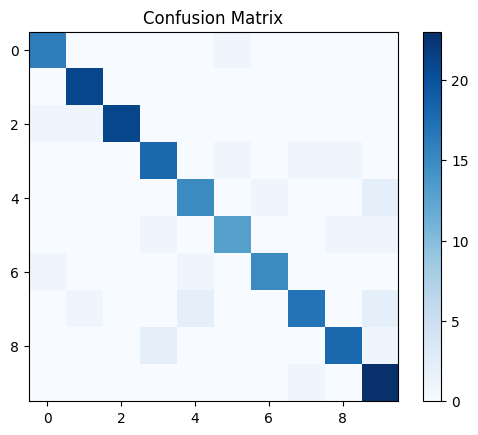

In [ ]:
# 마지막 테스트 결과 confusion matrix 시각화
plt.imshow(results[-1]['confusion_matrix'], cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()
